In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
import os
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool

In [3]:
class State(TypedDict):
    messages:Annotated[list, add_messages] 

In [4]:
load_dotenv()
llm = ChatAnthropic(model='claude-sonnet-4-6')
llm

ChatAnthropic(profile={'max_input_tokens': 200000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-sonnet-4-6', max_tokens=64000, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [6]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)


graph = graph_builder.compile()

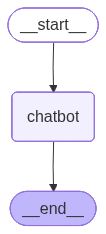

In [7]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")

In [8]:
response = graph.invoke({"messages":"Hi"})

In [9]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='8c4656cc-44ef-4f7b-bd99-104fd30bb5d3'),
 AIMessage(content='Hi there! How are you doing? Is there something I can help you with today? 😊', additional_kwargs={}, response_metadata={'id': 'msg_016pXvBpAQ4KfX7xbJcdf74N', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 8, 'output_tokens': 24, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb69a-5b78-7dc1-b956-fe4f0b7b4eb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 24, 'total_tokens': 32, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 

In [10]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="Hi! I'm doing well, thanks for asking. How are you doing? Is there something I can help you with today? 😊", additional_kwargs={}, response_metadata={'id': 'msg_01GdtyXSVrgPFf2vLxK8kx5E', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 12, 'output_tokens': 32, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb69a-6264-72c0-9943-d2c727926b57-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 32, 'total_tokens': 44, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}})]}


In [ ]:
tool = TavilySearch(max_results=2)
tool.invoke('What is LangGraph')

{'query': 'What is LangGraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? - Hugging Face Agents Course',
   'content': '# What is LangGraph ? `LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## When should I use LangGraph ? `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application involves a series of steps that need to be orchestrated in a specific way, with decisions being made at each junction point, **LangGraph provides the structure you need**. ## How does L

In [12]:
def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns: 
        int: output int

    """
    return a*b


In [13]:
tools = [tool, multiply]

In [14]:
llm_w_tools = llm.bind_tools(tools)
llm_w_tools

RunnableBinding(bound=ChatAnthropic(profile={'max_input_tokens': 200000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-sonnet-4-6', max_tokens=64000, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={}), kwargs={'tools': [{'name': 'tavily_search', 'input_schema': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user expli

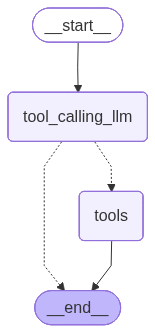

In [15]:
# Node Def
def tool_calling_llm(state:State):
    return {"messages":[llm_w_tools.invoke(state["messages"])]}

#Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END) 

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")


In [16]:
response = graph.invoke({"messages":"What is the recent ai news?"})

In [17]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================

[{'id': 'toolu_01Qev5enYBai1mTPxNbQiR7r', 'caller': {'type': 'direct'}, 'input': {'query': 'recent AI news', 'topic': 'news', 'time_range': 'week', 'search_depth': 'basic'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  tavily_search (toolu_01Qev5enYBai1mTPxNbQiR7r)
 Call ID: toolu_01Qev5enYBai1mTPxNbQiR7r
  Args:
    query: recent AI news
    topic: news
    time_range: week
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/ai-scare-trade-overreaction-nvidia-ceo-jensen-huang-software-nvda-2026-2", "title": "'The market got it wrong:' Nvidia CEO Jensen Huang sounded off o

In [18]:
response = graph.invoke({"messages":"11 times 25"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

11 times 25
================================== Ai Message ==================================

[{'id': 'toolu_01GVfLGB4Nrh5Bha2GB3rP8A', 'caller': {'type': 'direct'}, 'input': {'a': 11, 'b': 25}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01GVfLGB4Nrh5Bha2GB3rP8A)
 Call ID: toolu_01GVfLGB4Nrh5Bha2GB3rP8A
  Args:
    a: 11
    b: 25
================================= Tool Message =================================
Name: multiply

275


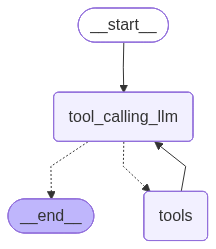

In [19]:
# Node Def
def tool_calling_llm(state:State):
    return {"messages":[llm_w_tools.invoke(state["messages"])]}

#Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm") 

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")


In [20]:
response = graph.invoke({"messages":"Give me the recent ai news and then 11 times 25"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then 11 times 25
================================== Ai Message ==================================

[{'text': "Sure! I'll fetch the latest AI news and calculate 11 × 25 at the same time!", 'type': 'text'}, {'id': 'toolu_0126VviuVppY25dSw34Y4CNS', 'caller': {'type': 'direct'}, 'input': {'query': 'recent AI news', 'time_range': 'week', 'topic': 'news'}, 'name': 'tavily_search', 'type': 'tool_use'}, {'id': 'toolu_01Mb8Loqngsv6FWcanzWs2i1', 'caller': {'type': 'direct'}, 'input': {'a': 11, 'b': 25}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  tavily_search (toolu_0126VviuVppY25dSw34Y4CNS)
 Call ID: toolu_0126VviuVppY25dSw34Y4CNS
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (toolu_01Mb8Loqngsv6FWcanzWs2i1)
 Call ID: toolu_01Mb8Loqngsv6FWcanzWs2i1
  Args:
    a: 11
    b: 25
================================= Tool Message ==============

#### Memory in Agentic Graph

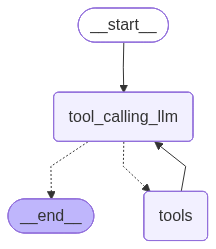

In [21]:
memory = MemorySaver()

#Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm") 

graph = builder.compile(checkpointer=memory)

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")

In [22]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages": "Hi my name is Mahad"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Mahad', additional_kwargs={}, response_metadata={}, id='857b789b-1c99-422d-8ff6-943b51942200'),
  AIMessage(content="Hi Mahad! It's great to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'id': 'msg_016voGvbiegPkABtDnUhYJ4L', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 2265, 'output_tokens': 22, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb69b-c5c1-70c3-b6fa-b117a1b43f39-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2265, 'output_tokens': 22, 'total_tokens': 2287, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral

In [23]:
response = graph.invoke({"messages": "What is my name?"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Mahad', additional_kwargs={}, response_metadata={}, id='857b789b-1c99-422d-8ff6-943b51942200'),
  AIMessage(content="Hi Mahad! It's great to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'id': 'msg_016voGvbiegPkABtDnUhYJ4L', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 2265, 'output_tokens': 22, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb69b-c5c1-70c3-b6fa-b117a1b43f39-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2265, 'output_tokens': 22, 'total_tokens': 2287, 'input_token_details': {'cache_creation': 0, 'cache_read': 0, 'ephemeral

In [25]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

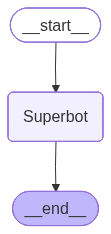

In [27]:
graph = StateGraph(State)

graph.add_node("Superbot", superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")


In [28]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':'Hi, My name is Mahad and I like basketball'}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hi Mahad! Nice to meet you! 🏀\n\nThat's cool that you like basketball! Are you more of a player yourself, or do you enjoy watching the game? Do you have a favorite team or player?", additional_kwargs={}, response_metadata={'id': 'msg_01MvN5X48aeuQwKCGrSk5WxB', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 19, 'output_tokens': 51, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb6ba-8ed6-7d11-9b80-03296b11ac42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 51, 'total_tokens': 70, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_inp

In [29]:
config = {"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({'messages':'Hi, My name is Mahad and I like basketball'}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Mahad and I like basketball', additional_kwargs={}, response_metadata={}, id='96c3f3fa-10c3-479b-b253-69553a24db82')]}
{'messages': [HumanMessage(content='Hi, My name is Mahad and I like basketball', additional_kwargs={}, response_metadata={}, id='96c3f3fa-10c3-479b-b253-69553a24db82'), AIMessage(content="Hi Mahad! Nice to meet you! 🏀\n\nThat's cool that you like basketball! Are you a fan of a particular team, or do you enjoy playing the game yourself? Or both?", additional_kwargs={}, response_metadata={'id': 'msg_01NmXJvoCDLV5dhMLZtQJNxM', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 19, 'output_tokens': 47, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-s

In [30]:
for chunk in graph_builder.stream({'messages':'I also like cricket'}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Mahad and I like basketball', additional_kwargs={}, response_metadata={}, id='96c3f3fa-10c3-479b-b253-69553a24db82'), AIMessage(content="Hi Mahad! Nice to meet you! 🏀\n\nThat's cool that you like basketball! Are you a fan of a particular team, or do you enjoy playing the game yourself? Or both?", additional_kwargs={}, response_metadata={'id': 'msg_01NmXJvoCDLV5dhMLZtQJNxM', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 19, 'output_tokens': 47, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cb6bb-f92a-7ee0-a3dd-bd87a661d508-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19,

In [32]:
config = {"configurable":{"thread_id":"5"}}

async for chunk in graph_builder.astream_events({'messages':'Hi, My name is Mahad and I like basketball'}, config, version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Mahad and I like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019cb6bf-fd2a-7250-850e-a202ed0b90f0', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Mahad and I like basketball', additional_kwargs={}, response_metadata={}, id='10e2b0f9-1bfb-434d-9056-a2a8f2ac44a0')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019cb6bf-fd2d-71d1-8358-d215ff70f55b', 'metadata': {'thread_id': '5', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:b4139f3d-2b86-2fd2-a063-b66e6d83ec91'}, 'parent_ids': ['019cb6bf-fd2a-7250-850e-a202ed0b90f0']}
{'event': 'on_chain_stream', 'run_id': '019cb6bf-fd2d-71d1-8358-d215ff70f55b', 'name': 'Superbot', 'tags': ['graph:step:1'], 'metadata'